In [1]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.wait_time_forecasting.paths import notebook_context
from modeling.wait_time_forecasting.gradient_boosting_attendance import (
    FEATURE_COLS,
    MODEL_FILENAME,
    _build_xgb_model,
    build_attendance_feature_table,
    select_best_params_cv,
)

ctx = notebook_context(project_root=PROJECT_ROOT, create_models_dir=True)
PROJECT_ROOT = ctx["project_root"]
DATA_DIR = ctx["data_dir"]
MODELS_DIR = ctx["models_dir"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)


PROJECT_ROOT: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code
DATA_DIR: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\modeling\data\raw
MODELS_DIR: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\modeling\artifacts\models


In [2]:
feature_df, weather_daily = build_attendance_feature_table(
    data_dir=DATA_DIR,
    park_name="PortAventura World",
)

df = feature_df.reset_index().rename(columns={"index": "date"}).copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df_model = df.dropna(subset=["date", "y", *FEATURE_COLS]).sort_values("date").reset_index(drop=True)

split_ratio = 0.8
unique_dates = pd.Series(df_model["date"].sort_values().unique())
split_idx = int(np.floor(len(unique_dates) * split_ratio))
split_idx = min(max(split_idx, 1), len(unique_dates) - 1)
split_date = unique_dates.iloc[split_idx - 1]

train_df = df_model[df_model["date"] <= split_date].copy().reset_index(drop=True)
test_df = df_model[df_model["date"] > split_date].copy().reset_index(drop=True)

print("total rows:", len(df_model))
print("train rows:", len(train_df))
print("test rows:", len(test_df))
print("split date:", split_date)


total rows: 817
train rows: 653
test rows: 164
split date: 2022-02-12 00:00:00


In [3]:
def build_feature_matrix(df_in: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    X = df_in.reindex(columns=feature_cols).copy()
    for c in feature_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
        med = X[c].median(skipna=True)
        X[c] = X[c].fillna(float(med) if pd.notna(med) else 0.0)
    return X


CV param sets:  17%|█▋        | 1/6 [00:02<00:11,  2.38s/set, best_mae=10,513.92]

[CV] Candidate 1/6 mean MAE: 10,513.92


CV param sets:  33%|███▎      | 2/6 [00:04<00:07,  1.99s/set, best_mae=10,513.92]

[CV] Candidate 2/6 mean MAE: 11,188.70


CV param sets:  50%|█████     | 3/6 [00:07<00:07,  2.48s/set, best_mae=10,513.92]

...

CV param sets:  83%|████████▎ | 5/6 [00:14<00:03,  3.27s/set, best_mae=10,142.36]

[CV] Candidate 5/6 mean MAE: 10,149.63


CV param sets: 100%|██████████| 6/6 [00:19<00:00,  3.27s/set, best_mae=10,142.36]

[CV] Candidate 6/6 mean MAE: 10,838.59


best params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'reg_alpha': 1.0}
7-day rows: 7
7-day MAE: 3252.9846540178573
7-day RMSE: 3790.4036462159524


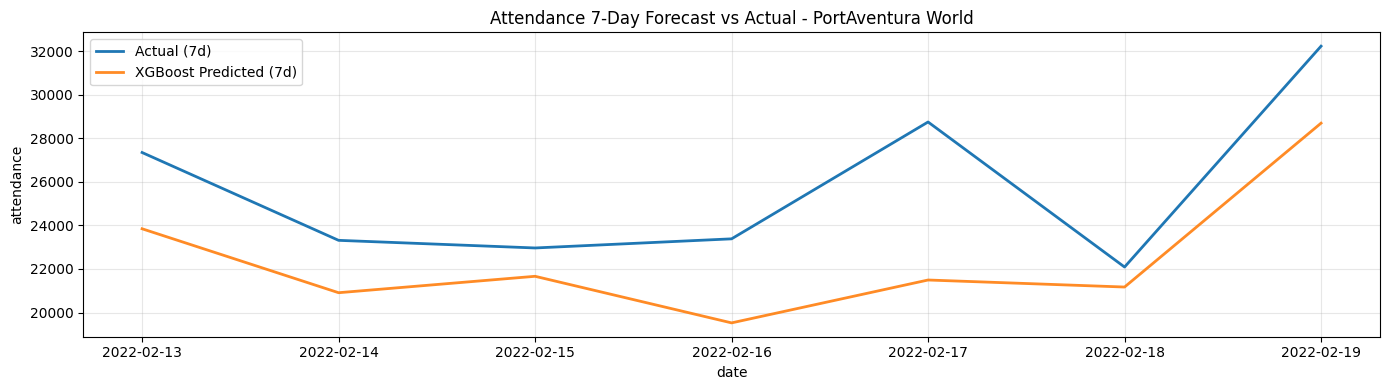

In [4]:
X_train = build_feature_matrix(train_df, list(FEATURE_COLS))
y_train = pd.to_numeric(train_df["y"], errors="coerce")

best_params, cv_scores = select_best_params_cv(
    X=X_train,
    y=y_train,
    cv_splits=5,
    random_state=42,
)

model = _build_xgb_model(best_params, random_state=42)
model.fit(X_train, y_train, verbose=False)

print("best params:", best_params)

# Evaluate on first 7 calendar days of the test window
if test_df.empty:
    raise ValueError("Test split is empty; cannot compute 7-day metrics.")

test_df = test_df.sort_values("date").reset_index(drop=True)
start_day = test_df["date"].dt.floor("D").min()
end_day_excl = start_day + pd.Timedelta(days=7)
test_7d = test_df[(test_df["date"] >= start_day) & (test_df["date"] < end_day_excl)].copy()

X_test_7d = build_feature_matrix(test_7d, list(FEATURE_COLS))
y_true = pd.to_numeric(test_7d["y"], errors="coerce").reset_index(drop=True)
y_pred = pd.Series(np.clip(model.predict(X_test_7d), 0, None), name="y_pred").reset_index(drop=True)

mask = y_true.notna() & y_pred.notna()
if mask.any():
    err = y_true[mask].to_numpy() - y_pred[mask].to_numpy()
    mae_7d = float(np.mean(np.abs(err)))
    rmse_7d = float(np.sqrt(np.mean(err ** 2)))
else:
    mae_7d = np.nan
    rmse_7d = np.nan

print("7-day rows:", len(test_7d))
print("7-day MAE:", mae_7d)
print("7-day RMSE:", rmse_7d)

pred_7d_df = pd.DataFrame({
    "date": pd.to_datetime(test_7d["date"], errors="coerce").reset_index(drop=True),
    "y_true": y_true,
    "y_pred": y_pred,
}).sort_values("date").reset_index(drop=True)

plt.figure(figsize=(14, 4))
plt.plot(pred_7d_df["date"], pred_7d_df["y_true"], label="Actual (7d)", linewidth=2)
plt.plot(pred_7d_df["date"], pred_7d_df["y_pred"], label="XGBoost Predicted (7d)", linewidth=2, alpha=0.9)
plt.title("Attendance 7-Day Forecast vs Actual - PortAventura World")
plt.xlabel("date")
plt.ylabel("attendance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
X_full = build_feature_matrix(df_model, list(FEATURE_COLS))
y_full = pd.to_numeric(df_model["y"], errors="coerce")
train_mask = y_full.notna()

final_model = _build_xgb_model(best_params, random_state=42)
final_model.fit(X_full.loc[train_mask], y_full.loc[train_mask], verbose=False)

artifact = {
    "model": final_model,
    "feature_cols": list(FEATURE_COLS),
    "best_params": dict(best_params),
    "cv_scores": cv_scores,
    "park_name": "PortAventura World",
    "train_start_date": df_model["date"].min(),
    "train_end_date": df_model["date"].max(),
}

model_path = MODELS_DIR / MODEL_FILENAME
joblib.dump(artifact, model_path)

metrics_df = pd.DataFrame([
    {
        "metric": "cv_mean_mae_best",
        "value": float(min(r["mean_mae"] for r in cv_scores)),
    },
    {
        "metric": "mae_7d",
        "value": float(mae_7d) if pd.notna(mae_7d) else np.nan,
    },
    {
        "metric": "rmse_7d",
        "value": float(rmse_7d) if pd.notna(rmse_7d) else np.nan,
    },
])

print("saved model:", model_path)
metrics_df


saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\modeling\artifacts\models\attendace_gradient_boosting.joblib


,metric,value
0,cv_mean_mae_best,10142.357382
1,mae_7d,3252.984654
2,rmse_7d,3790.403646
